<a href="https://colab.research.google.com/github/Mamatha07-T/Diabetes_disease_progression_ML/blob/main/diabetes_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (442, 10)

Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target Sample: [151.  75. 141. 206. 135.]


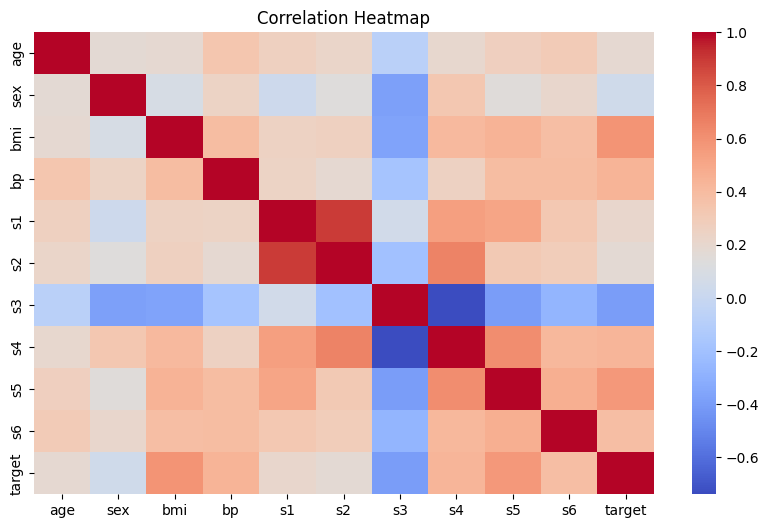


Model Comparison:

               Model  R2 Score        MAE       RMSE
2   Lasso Regression  0.454650  44.287986  53.752634
0  Linear Regression  0.454331  44.288196  53.768366
4  Gradient Boosting  0.448174  45.497190  54.070845
3      Random Forest  0.445403  44.466124  54.206459
1   Ridge Regression  0.392754  47.802203  56.721095

Best Model Selected: Lasso Regression

Enter Patient Details:
BMI Range: 15 – 45
Blood Pressure Range: 80 – 180 mmHg
S5 (Blood Sugar Indicator) Range: 3.0 – 6.5

Enter BMI: 41
Enter Blood Pressure: 85
Enter S5 Value: 4.0

Prediction Result:
Predicted Disease Progression Value: 52608.18
Risk Category: High Risk 🔴


In [1]:

# 1. IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")


# 2. DATA LOADING & EXPLORATION

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print("Dataset Shape:", X.shape)
print("\nFeature Names:", list(X.columns))
print("\nTarget Sample:", y[:5])

# Create combined dataframe for EDA
df = X.copy()
df["target"] = y


# 3. EXPLORATORY DATA ANALYSIS (EDA)

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

"""
Observation:
BMI, BP, and S5 show relatively strong correlation
with disease progression compared to other features.
"""


# 4. FEATURE ENGINEERING (CLINICAL REASONING)

"""
Selected Features:
- BMI : Obesity is a major diabetes risk factor
- BP  : Hypertension is strongly linked with complications
- S5  : Blood sugar / triglyceride marker (metabolic risk)

Age and Sex are excluded here to keep the model:
- Simple
- Interpretable
- Focused on modifiable clinical parameters
"""

selected_features = ["bmi", "bp", "s5"]
X_selected = X[selected_features]


# 5. DATA PREPROCESSING

"""
The diabetes dataset is already standardized
(mean = 0, standard deviation = 1).
"""

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


# 6. MODEL TRAINING (5 ALGORITHMS)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results, columns=["Model", "R2 Score", "MAE", "RMSE"]
).sort_values(by="R2 Score", ascending=False)

print("\nModel Comparison:\n")
print(results_df)


# 7. BEST MODEL SELECTION

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nBest Model Selected: {best_model_name}")


# 8. FEATURE IMPORTANCE (MODEL REASONING)

if best_model_name in ["Random Forest", "Gradient Boosting"]:
    importances = best_model.feature_importances_

    plt.figure(figsize=(6, 4))
    plt.bar(selected_features, importances)
    plt.title("Feature Importance")
    plt.ylabel("Importance Score")
    plt.show()



# 9. USER INPUT

print("\nEnter Patient Details:")
print("BMI Range: 15 – 45")
print("Blood Pressure Range: 80 – 180 mmHg")
print("S5 (Blood Sugar Indicator) Range: 3.0 – 6.5\n")

bmi = float(input("Enter BMI: "))
bp = float(input("Enter Blood Pressure: "))
s5 = float(input("Enter S5 Value: "))

# Optional safety warnings
if bp > 180:
    print("\n⚠️ Warning: Blood Pressure is above normal clinical range.")

user_input = np.array([[bmi, bp, s5]])



# 10. PREDICTION & RISK INTERPRETATION

prediction = best_model.predict(user_input)[0]

if prediction < 150:
    risk = "Low Risk 🟢"
elif prediction < 250:
    risk = "Moderate Risk 🟠"
else:
    risk = "High Risk 🔴"

print("\nPrediction Result:")
print(f"Predicted Disease Progression Value: {prediction:.2f}")
print(f"Risk Category: {risk}")
